# Pregunta 1
Implemente un detector de movimiento por diferencia de cuadros y aplíquelo sobre la secuencia
de imágenes (carpetas mora_mov, sephanoides_mov y vigilancia_mov). Muestre ejemplos de
detección de movimiento y explique la forma que adoptan los pixeles de primer plano.

In [40]:
import cv2 as cv
import numpy as np
import os
from matplotlib import pyplot as plt
from matplotlib import gridspec
import natsort

In [41]:
def detector_mov_diferencia(file_path, threshold=30):
    # Calcula la diferencia entre cuadros consecutivos para detectar movimiento
    images = sorted([img for img in os.listdir(file_path) if img.endswith((".jpg", ".bmp"))])
    movimiento = []
    for i in range(1, len(images)):
        img1 = cv.imread(os.path.join(file_path, images[i-1]), cv.IMREAD_GRAYSCALE)
        img2 = cv.imread(os.path.join(file_path, images[i]), cv.IMREAD_GRAYSCALE)
        #quiero las solo las differencias negativas 
        diff = cv.subtract(img1, img2)
        _, thresh = cv.threshold(diff, threshold, 255, cv.THRESH_BINARY)
        movimiento.append(thresh)
    return movimiento
labmov = 'Lab-Mov'
mora_path = os.path.join(labmov, 'mora_mov')
sephanoides_path = os.path.join(labmov, 'sephanoides_mov')
vigilancia_path = os.path.join(labmov, 'vigilancia_mov')
estacionamiento_path = os.path.join(labmov, 'estacionamiento')

estacionamiento_dif = detector_mov_diferencia(estacionamiento_path)
mora_dif = detector_mov_diferencia(mora_path)
sephanoides_dif = detector_mov_diferencia(sephanoides_path)
vigilancia_dif = detector_mov_diferencia(vigilancia_path)

In [42]:
# Guardar resultados
def save_results(movimiento, folder_name):
    if not os.path.exists(folder_name):
        os.makedirs(folder_name)
    for i, img in enumerate(movimiento):
        cv.imwrite(os.path.join(folder_name, f"mov_{i+1:03d}.jpg"), img)
        
results = 'Results_1'

mora_dif_path = os.path.join(results, 'mora_dif')
sephanoides_dif_path = os.path.join(results, 'sephanoides_dif')
vigilancia_dif_path = os.path.join(results, 'vigilancia_dif')

save_results(mora_dif,mora_dif_path) 
save_results(sephanoides_dif,sephanoides_dif_path) 
save_results(vigilancia_dif,vigilancia_dif_path)


# Pregunta 2
Utilizando la secuencia de imágenes de la carpeta “sephanoides_fondo” y “vigilancia_fondo”,
genere un modelo de fondo de dos matrices calculando el promedio de los cuadros (matriz 1) y
la desviación estándar (matriz 2). Elija un umbral apropiado y aplíquelo para detectar
movimiento sobre las secuencias de imágenes respectivas (sephanoides_mov y vigilancia_mov).
Entregue las matrices del modelo de fondo. Muestre ejemplos de detección de movimiento y
explique la forma que adoptan los pixeles de primer plano.


In [43]:
#utilizando sephanoides_fondo y vigilancia_fondo. 
#genere un modelo de fondo de dos matrices calculando el promedio de los cuadros (matriz 1) y la desviación estándar (matriz 2)
def modelo_fondo(file_path):
    """
    Calcula el promedio y la desviación estándar píxel a píxel 
    de todas las imágenes en file_path.
    """
    images = sorted([img for img in os.listdir(file_path) if img.lower().endswith((".jpg", ".bmp"))])
    if not images:
        raise ValueError("No se encontraron imágenes en la carpeta.")

    # Inicializar acumuladores
    sum_img = None
    sum_sq_img = None
    count = 0

    for img_name in images:
        img = cv.imread(os.path.join(file_path, img_name), cv.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Advertencia: no se pudo leer {img_name}, se omitirá.")
            continue

        img = img.astype(np.float32)

        if sum_img is None:
            sum_img = np.zeros_like(img, dtype=np.float32)
            sum_sq_img = np.zeros_like(img, dtype=np.float32)

        sum_img += img
        sum_sq_img += img**2
        count += 1

    if count == 0:
        raise ValueError("No se pudo cargar ninguna imagen válida.")

    # Calcular promedio y desviación estándar
    mean_img = (sum_img / count).astype(np.uint8)
    std_img = np.sqrt((sum_sq_img / count) - (mean_img.astype(np.float32))**2).astype(np.uint8)

    return mean_img, std_img



# Detectar movimiento usando el modelo de fondo, umbralizando la diferencia entre el cuadro actual y el modelo de fondo
def detector_mov_fondo(file_path, mean_img, std_img, alpha=2):
    images = sorted([img for img in os.listdir(file_path) if img.endswith((".jpg", ".bmp"))])
    movimiento = []
    for img_name in images:
        img = cv.imread(os.path.join(file_path, img_name), cv.IMREAD_GRAYSCALE)
        # diff = cv.absdiff(img, mean_img)
        # mean_mat = np.full(img.shape, mean_img, dtype=np.uint8)
        # Umbral por píxel: alpha * desviación estándar
        thresh_num = mean_img - alpha * std_img
        diff = (img )
        
        # Comparación por elemento (matricial)
        thresh = np.where(diff <= thresh_num, 255, 0).astype(np.uint8)

        movimiento.append(thresh)
    return movimiento


In [44]:
# Generar modelos de fondo
sephanoides_background_path = os.path.join(labmov, 'sephanoides_fondo')
vigilancia_background_path = os.path.join(labmov, 'vigilancia_fondo')
sephanoides_mean, sephanoides_std = modelo_fondo(sephanoides_background_path)
vigilancia_mean, vigilancia_std = modelo_fondo(vigilancia_background_path) 

# Guardar los modelos de fondo (mean/std) en Results_2 como .npy y visualizar como .png
results = 'Results_2'
# Crear carpetas para almacenar los modelos
seph_model_dir = os.path.join(results, 'sephanoides_model')
vig_model_dir = os.path.join(results, 'vigilancia_model')
os.makedirs(seph_model_dir, exist_ok=True)
os.makedirs(vig_model_dir, exist_ok=True)
# Guardar arrays NumPy
np.save(os.path.join(seph_model_dir, 'mean.npy'), sephanoides_mean)
np.save(os.path.join(seph_model_dir, 'std.npy'), sephanoides_std)
np.save(os.path.join(vig_model_dir, 'mean.npy'), vigilancia_mean)
np.save(os.path.join(vig_model_dir, 'std.npy'), vigilancia_std)
# También guardar visualizaciones (guardar como imágenes) para inspección rápida

cv.imwrite(os.path.join(seph_model_dir, 'mean.png'), sephanoides_mean)
cv.imwrite(os.path.join(seph_model_dir, 'std.png'), sephanoides_std)
cv.imwrite(os.path.join(vig_model_dir, 'mean.png'), vigilancia_mean)
cv.imwrite(os.path.join(vig_model_dir, 'std.png'), vigilancia_std)

# Detectar movimiento usando el modelo de fondo
sephanoides_fondo = detector_mov_fondo(sephanoides_path, sephanoides_mean, sephanoides_std, alpha = 1.5)
vigilancia_fondo = detector_mov_fondo(vigilancia_path, vigilancia_mean, vigilancia_std, alpha = 1.5)

# Guardar resultados de detección
sephanoides_fondo_path = os.path.join(results, 'sephanoides_fondo')
vigilancia_fondo_path = os.path.join(results, 'vigilancia_fondo')  
save_results(sephanoides_fondo,sephanoides_fondo_path)
save_results(vigilancia_fondo,vigilancia_fondo_path)



# Pregunta 3
Usando la detección de movimiento anterior, calcule el histograma proyectado por columnas
(suma de pixeles por columna) y el histograma proyectado por filas (suma de pixeles por fila)
Con esta información, encierre en una caja de dimensiones adecuadas el blob de la detección de
movimiento.



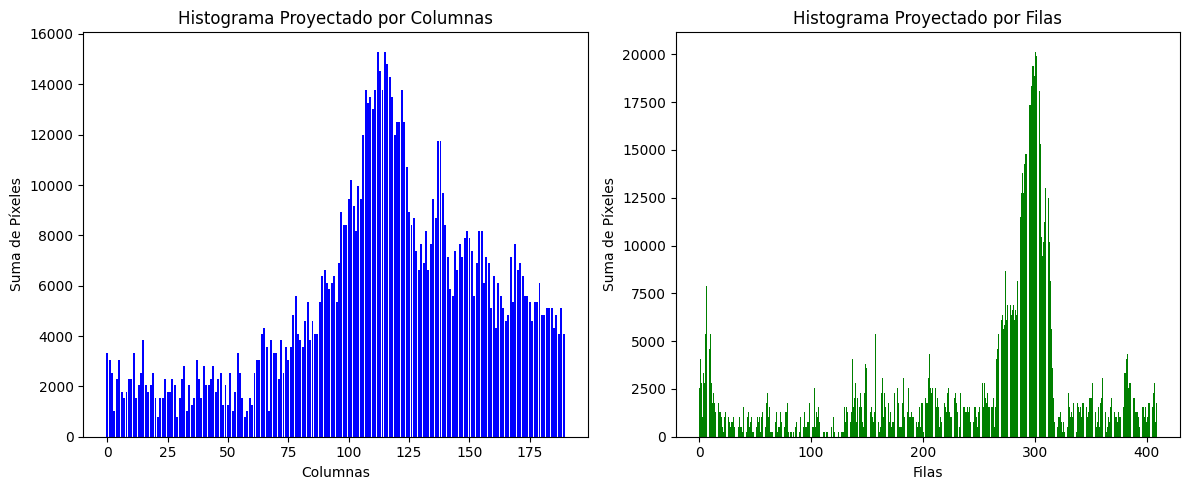

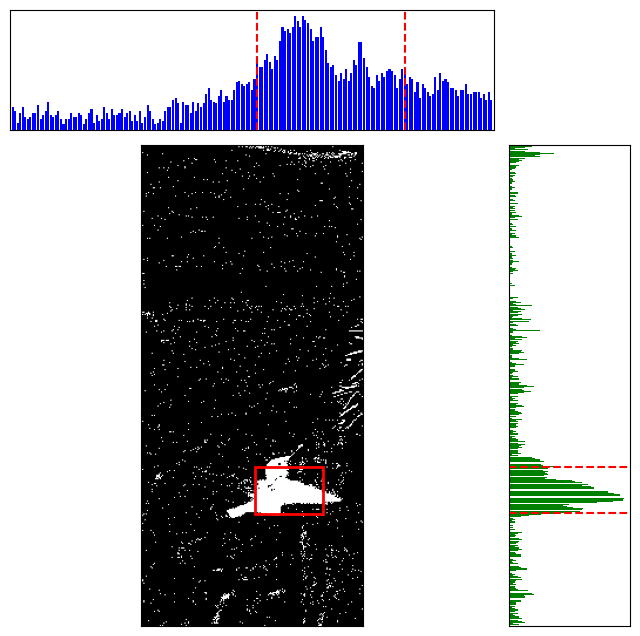

In [45]:
# Calcular el histograma proyectado por columnas y filas de las imágenes de movimiento detectado
def histograma_proyectado(movimiento):
    x_sum = np.sum(movimiento, axis=0)
    y_sum = np.sum(movimiento, axis=1)
    # plot
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.bar(range(len(x_sum)), x_sum, color='blue')
    plt.title('Histograma Proyectado por Columnas')
    plt.xlabel('Columnas')
    plt.ylabel('Suma de Píxeles')
    plt.subplot(1, 2, 2)
    plt.bar(range(len(y_sum)), y_sum, color='green')
    plt.title('Histograma Proyectado por Filas')
    plt.xlabel('Filas')
    plt.ylabel('Suma de Píxeles')
    plt.tight_layout()
    plt.show()
    
    return x_sum, y_sum

def blob(img, treshold=0):
    hist_col, hist_row = histograma_proyectado(img)
    x_min = np.min(np.where(hist_col > treshold))
    x_max = np.max(np.where(hist_col > treshold))
    y_min = np.min(np.where(hist_row > treshold))
    y_max = np.max(np.where(hist_row > treshold))
    return (x_min, y_min), (x_max, y_max)

def histograma_proyectado_con_visualizacion(movimiento, treshold=0):
    x_sum = np.sum(movimiento, axis=0)
    y_sum = np.sum(movimiento, axis=1)

    (x_min, y_min), (x_max, y_max) = blob(movimiento, treshold)
    fig = plt.figure(figsize=(8, 8))
    gs = gridspec.GridSpec(2, 2, width_ratios=[4, 1], height_ratios=[1, 4],
                           wspace=0.05, hspace=0.05)
    ax_histx = plt.subplot(gs[0, 0])
    ax_histx.bar(range(len(x_sum)), x_sum, color='blue')
    ax_histx.axvline(x_min, color='red', linestyle='--')
    ax_histx.axvline(x_max, color='red', linestyle='--')
    ax_histx.set_xlim(0, movimiento.shape[1])
    ax_histx.set_xticks([])
    ax_histx.set_yticks([])

    ax_img = plt.subplot(gs[1, 0])
    ax_img.imshow(movimiento, cmap='gray')
    rect = plt.Rectangle((x_min, y_min), x_max - x_min, y_max - y_min,
                         edgecolor='red', facecolor='none', linewidth=2)
    ax_img.add_patch(rect)
    ax_img.set_xticks([])
    ax_img.set_yticks([])

    ax_histy = plt.subplot(gs[1, 1])
    ax_histy.barh(range(len(y_sum)), y_sum, color='green')
    ax_histy.axhline(y_min, color='red', linestyle='--')
    ax_histy.axhline(y_max, color='red', linestyle='--')
    ax_histy.set_ylim(movimiento.shape[0], 0)
    ax_histy.set_xticks([])
    ax_histy.set_yticks([])

    plt.show()

    return (x_min, y_min), (x_max, y_max)

top_left, bottom_right = histograma_proyectado_con_visualizacion(sephanoides_fondo[0], treshold=8000)
def corners_to_width_and_center(top_left, bottom_right):
    x_min, y_min = top_left
    x_max, y_max = bottom_right
    w = x_max - x_min
    h = y_max - y_min
    x = (x_max + x_min) // 2
    y = (y_max + y_min) // 2
    return np.array([w, h, x, y])


# Pregunta 4
Utilizando la información de la posición de la caja en el cuadro actual y la de los cuadros
anteriores, estime la posición del objeto para el cuadro siguiente. Dibuje la caja estimada y
compárela con la obtenida usando el procedimiento descrito en 3. Comente.


In [46]:
# gamma representa un vector de dimensión 4 que
# contiene la informacion del alto (height), 
# ancho (width) y posición del centro en la imagen
# (coordenadas en x e y)

def gamma(prev_frame, prev_prev_frame, *params):
    if len(params) != 4:
        raise ValueError('Debes insertar 4 parametros A, B, C, D')
    A, B, C, D = params
    K = np.diag([A, B, C, D])
    return (K+np.eye(4))*prev_frame - K*prev_prev_frame

import numpy as np
import cv2 as cv
import os

def gamma(prev_frame_vec, prev_prev_frame_vec, *params):
    if len(params) != 4:
        raise ValueError('Debes insertar 4 parametros A, B, C, D')
    A, B, C, D = params
    K = np.diag([A, B, C, D])
    return (K + np.eye(4)) @ prev_frame_vec - K @ prev_prev_frame_vec


def detector_diff_cuadros(file_path, threshold=30):
    images = natsort.natsorted([img for img in os.listdir(file_path) if img.endswith((".jpg", ".bmp"))])
    movimiento = []
    prev_frame = None
    prev_prev_frame = None
    prev_box = None
    prev_prev_box = None

    for i, img_name in enumerate(images):
        img = cv.imread(os.path.join(file_path, img_name), cv.IMREAD_GRAYSCALE)

        if prev_frame is None:
            prev_frame = img
            continue
        if prev_prev_frame is None:
            prev_prev_frame = prev_frame
            prev_frame = img
            continue

        # Diferencia entre cuadros consecutivos
        diff = cv.absdiff(prev_frame, prev_prev_frame)
        _, thresh = cv.threshold(diff, threshold, 255, cv.THRESH_BINARY)

        # Encontrar contornos (áreas de movimiento)
        contours, _ = cv.findContours(thresh, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)

        if contours:
            # Caja delimitadora más grande
            c = max(contours, key=cv.contourArea)
            x, y, w, h = cv.boundingRect(c)
            cx, cy = x + w // 2, y + h // 2
            box_vec = np.array([h, w, cx, cy], dtype=float)

            # Dibujar caja real
            color_frame = cv.cvtColor(prev_frame, cv.COLOR_GRAY2BGR)
            cv.rectangle(color_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)  # verde = real

            # Si tenemos 2 cajas previas → estimar la siguiente
            if prev_box is not None and prev_prev_box is not None:
                pred_box = gamma(prev_box, prev_prev_box, 1, 1, 1, 1)
                h_pred, w_pred, cx_pred, cy_pred = pred_box.astype(int)
                x_pred, y_pred = cx_pred - w_pred // 2, cy_pred - h_pred // 2
                cv.rectangle(color_frame, (x_pred, y_pred),
                             (x_pred + w_pred, y_pred + h_pred), (0, 0, 255), 2)  # rojo = estimado

            movimiento.append(color_frame)

            prev_prev_box = prev_box
            prev_box = box_vec

        prev_prev_frame = prev_frame
        prev_frame = img

    return movimiento


sephanoides_diff_cuadros = detector_diff_cuadros(sephanoides_path, threshold=30)
vigilancia_diff_cuadros = detector_diff_cuadros(vigilancia_path, threshold=30)

# Guardar resultados
results = 'Results_4'
sephanoides_diff_cuadros_path = os.path.join(results, 'sephanoides_diff_cuadros')
vigilancia_diff_cuadros_path = os.path.join(results, 'vigilancia_diff_cuadros')  
save_results(sephanoides_diff_cuadros,sephanoides_diff_cuadros_path)
save_results(vigilancia_diff_cuadros,vigilancia_diff_cuadros_path)



# Pregunta 5
Utilice el detector por diferencia de cuadros implementado y aplíquelo sobre la secuencia de
imágenes “estacionamiento”. Muestre ejemplos de detección de movimiento y explique la forma
que adoptan los pixeles de primer plano. Obtenga los bounding boxes de cada blob. Identifique
los principales problemas de utilizar este método.


In [47]:
estacionamiento_diff_cuadros = detector_diff_cuadros(estacionamiento_path, threshold=30)

# Guardar resultados
results = 'Results_5'
estacionamiento_diff_cuadros_path = os.path.join(results, 'estacionamiento_diff_cuadros')
save_results(estacionamiento_diff_cuadros, estacionamiento_diff_cuadros_path)